# LAB TASKS
## Task 1: Simple Linear Regression:-
- Load dataset: Use the Diabetes dataset from sklearn.datasets. Select one feature (bmi) to predict
the target (disease progression).
- Perform Exploratory Data Analysis (EDA):
- Plot scatter plot of BMI vs. Disease Progression.
- Check correlation.
- Implement Simple Linear Regression using sklearn.linear_model.LinearRegression:
- Split data into training and testing sets.
- Fit the model and predict disease progression.
- Plot the regression line on the scatter plot.
- Evaluate the model using:
- Mean Squared Error (MSE)
- R² score
## Task 2: Multivariate Linear Regression: -
- Load dataset: Use the same Diabetes dataset, but include all 10 features to predict disease
progression.
- Perform EDA:
- Generate a correlation heatmap between features and the target.
- Create pair plots for selected features vs. target.
- Implement Multivariate Linear Regression:
- Use all independent variables to predict the target.
- Fit and predict using the model.
- Compare actual vs. predicted values using:
- Scatter plot (predicted vs. actual).
- Residual plot.
- Evaluate model performance with:
- MSE
- RMSE
- R² score
- Which independent variable contribute
## Task 3: Experimentation: -
- Compare performance of simple vs. multivariate regression in terms of evaluation metrics.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
diabetes = load_diabetes(as_frame=True)
df = diabetes.frame
X = df[["bmi"]]
y = df["target"]
correlation = df["bmi"].corr(df["target"])
print(f"Correlation between BMI and Disease Progression: {correlation:.4f}")

Correlation between BMI and Disease Progression: 0.5865


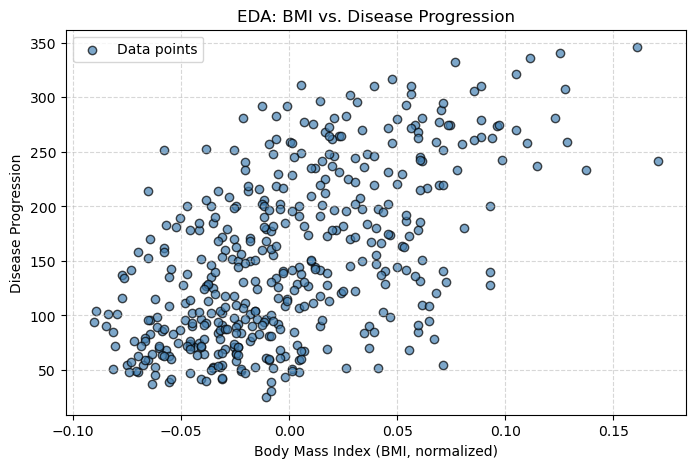

In [2]:
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color="steelblue", alpha=0.7, edgecolors="k", label="Data points")
plt.title("EDA: BMI vs. Disease Progression")
plt.xlabel("Body Mass Index (BMI, normalized)")
plt.ylabel("Disease Progression")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.show()

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(f"Intercept (theta_0): {model.intercept_:.2f}")
print(f"Slope (theta_1):     {model.coef_[0]:.2f}")

Intercept (theta_0): 152.00
Slope (theta_1):     998.58


C:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


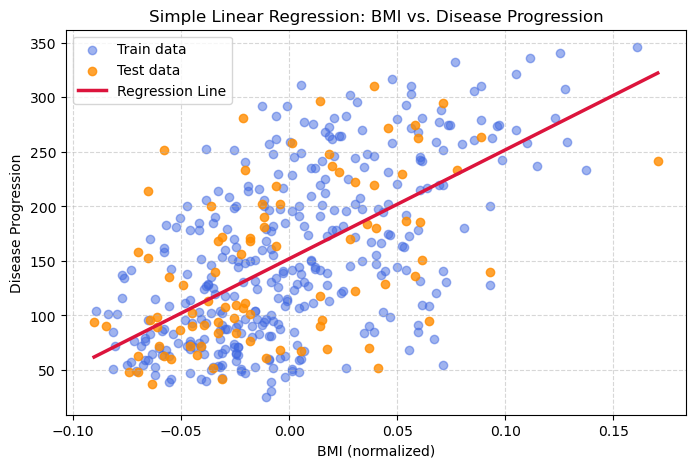

In [4]:
x_range = np.linspace(X["bmi"].min(), X["bmi"].max(), 100).reshape(-1, 1)
y_range_pred = model.predict(x_range)

plt.figure(figsize=(8, 5))
plt.scatter(
    X_train, y_train, color="royalblue", alpha=0.5, label="Train data"
)
plt.scatter(
    X_test, y_test, color="darkorange", alpha=0.8, label="Test data"
)
plt.plot(
    x_range,
    y_range_pred,
    color="crimson",
    linewidth=2.5,
    label="Regression Line",
)
plt.title("Simple Linear Regression: BMI vs. Disease Progression")
plt.xlabel("BMI (normalized)")
plt.ylabel("Disease Progression")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [5]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Model Evaluation (Test Set) ---")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² Score:                 {r2:.4f}")


--- Model Evaluation (Test Set) ---
Mean Squared Error (MSE): 4061.83
R² Score:                 0.2334


In [6]:
X = df.drop(columns=["target"])
y = df["target"]

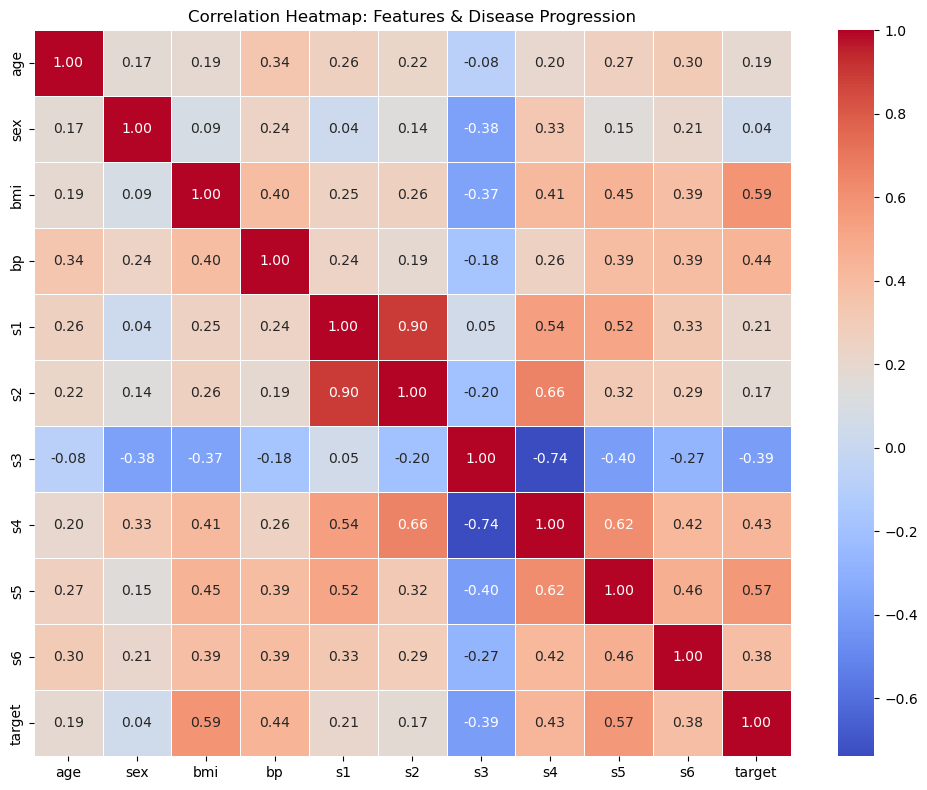

In [8]:
import seaborn as sns
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap: Features & Disease Progression")
plt.tight_layout()
plt.show()

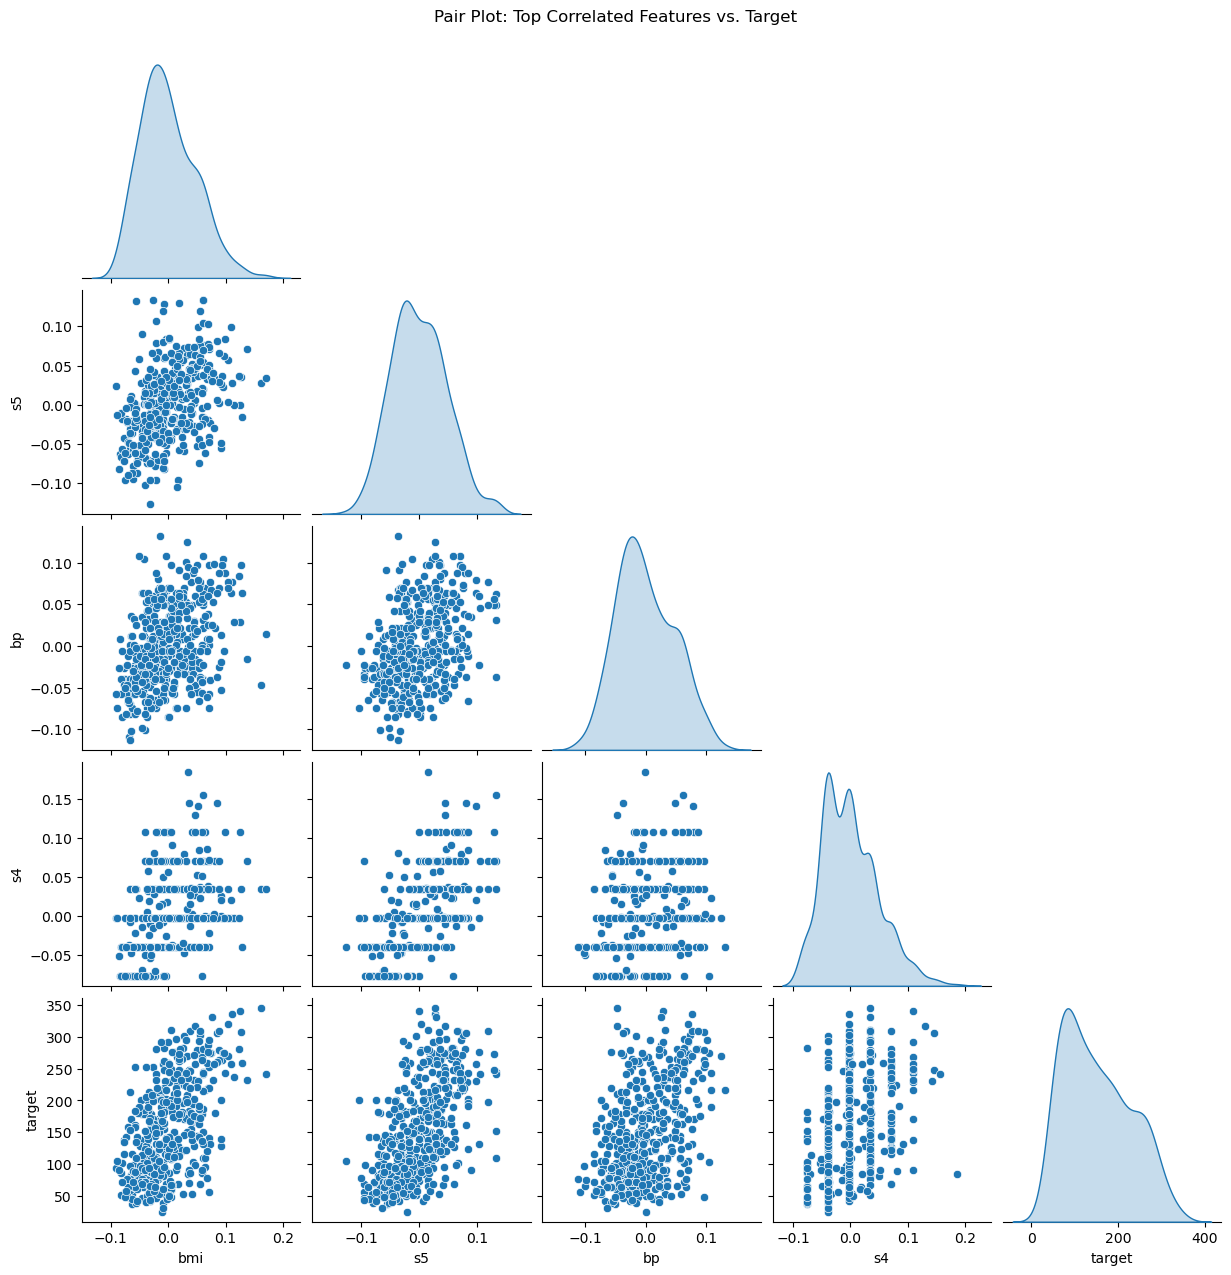

In [9]:
top_features = ["bmi", "s5", "bp", "s4", "target"]
sns.pairplot(df[top_features], kind="scatter", diag_kind="kde", corner=True)
plt.suptitle("Pair Plot: Top Correlated Features vs. Target", y=1.02)
plt.show()

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
residuals = y_test - y_pred

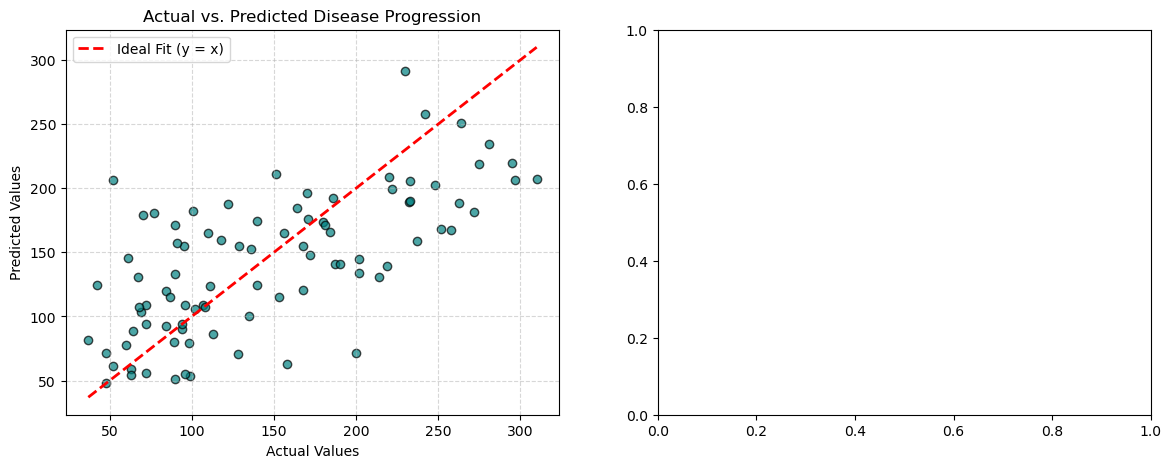

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_test, y_pred, color="teal", alpha=0.7, edgecolors="k")
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2, label="Ideal Fit (y = x)")
axes[0].set_xlabel("Actual Values")
axes[0].set_ylabel("Predicted Values")
axes[0].set_title("Actual vs. Predicted Disease Progression")
axes[0].grid(True, linestyle="--", alpha=0.5)
axes[0].legend()

In [12]:
axes[1].scatter(y_pred, residuals, color="darkorange", alpha=0.7, edgecolors="k")
axes[1].axhline(y=0, color="red", linestyle="--", lw=2)
axes[1].set_xlabel("Predicted Values")
axes[1].set_ylabel("Residuals (Actual - Predicted)")
axes[1].set_title("Residual Plot")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [13]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("--- Model Evaluation (Test Set) ---")
print(f"Mean Squared Error (MSE):      {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score:                       {r2:.4f}")

--- Model Evaluation (Test Set) ---
Mean Squared Error (MSE):      2900.19
Root Mean Squared Error (RMSE): 53.85
R² Score:                       0.4526


In [14]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_,
    "Absolute_Impact": np.abs(model.coef_)
}).sort_values(by="Absolute_Impact", ascending=False)

print("\n--- Feature Coefficients ---")
print(coefficients.to_string(index=False))


--- Feature Coefficients ---
Feature  Coefficient  Absolute_Impact
     s1  -931.488846       931.488846
     s5   736.198859       736.198859
    bmi   542.428759       542.428759
     s2   518.062277       518.062277
     bp   347.703844       347.703844
     s4   275.317902       275.317902
    sex  -241.964362       241.964362
     s3   163.419983       163.419983
     s6    48.670657        48.670657
    age    37.904021        37.904021
